## Import + load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import os

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
master_df = pd.read_csv(os.path.join(base_dir, 'data', 'processed', 'master_df.csv'), index_col=0)

print("✅ Libraries loaded")
print(f"✅ master_df loaded — {master_df.shape}")

✅ Libraries loaded
✅ master_df loaded — (3, 19)


## Define Market Sizing Data

In [4]:
# TAM, CAGR, PE capital deployed — sourced from IHRSA, PitchBook, IBISWorld
market_data = {
    'HVLP': {
        'TAM_B':        20.0,    # $20B total addressable market
        'CAGR':         6.7,     # % annual growth
        'PE_Capital_B': 3.5,     # $B PE capital deployed 2019–2024
        'Locations':    3200,    # US location count (Planet Fitness ~2400 + others)
        'Members_M':    21.0,    # total members in millions
        'Avg_Rev_Site': 1.8,     # avg annual revenue per site $M
    },
    'Boutique': {
        'TAM_B':        5.4,
        'CAGR':         12.8,    # higher growth rate despite smaller TAM
        'PE_Capital_B': 1.5,
        'Locations':    8500,    # fragmented — F45, Orangetheory, Club Pilates etc
        'Members_M':    6.2,
        'Avg_Rev_Site': 0.6,
    },
    'Digital': {
        'TAM_B':        8.1,
        'CAGR':         3.2,     # slowing post-COVID
        'PE_Capital_B': 0.2,
        'Locations':    0,       # no physical locations
        'Members_M':    9.8,     # app/platform users
        'Avg_Rev_Site': 0,
    },
}

categories = list(market_data.keys())
colors = {'HVLP': '#4f98a3', 'Boutique': '#f97316', 'Digital': '#a78bfa'}

for cat, d in market_data.items():
    sam = d['TAM_B'] * 0.35   # serviceable addressable market ~35% of TAM
    som = sam * 0.12           # serviceable obtainable market ~12% of SAM
    d['SAM_B'] = round(sam, 2)
    d['SOM_B'] = round(som, 2)
    print(f"{cat:<10}  TAM: ${d['TAM_B']}B  |  SAM: ${d['SAM_B']}B  |  SOM: ${d['SOM_B']}B  |  CAGR: {d['CAGR']}%  |  PE: ${d['PE_Capital_B']}B")

HVLP        TAM: $20.0B  |  SAM: $7.0B  |  SOM: $0.84B  |  CAGR: 6.7%  |  PE: $3.5B
Boutique    TAM: $5.4B  |  SAM: $1.89B  |  SOM: $0.23B  |  CAGR: 12.8%  |  PE: $1.5B
Digital     TAM: $8.1B  |  SAM: $2.83B  |  SOM: $0.34B  |  CAGR: 3.2%  |  PE: $0.2B


## TAM/SAM/SOM Funnel Chart

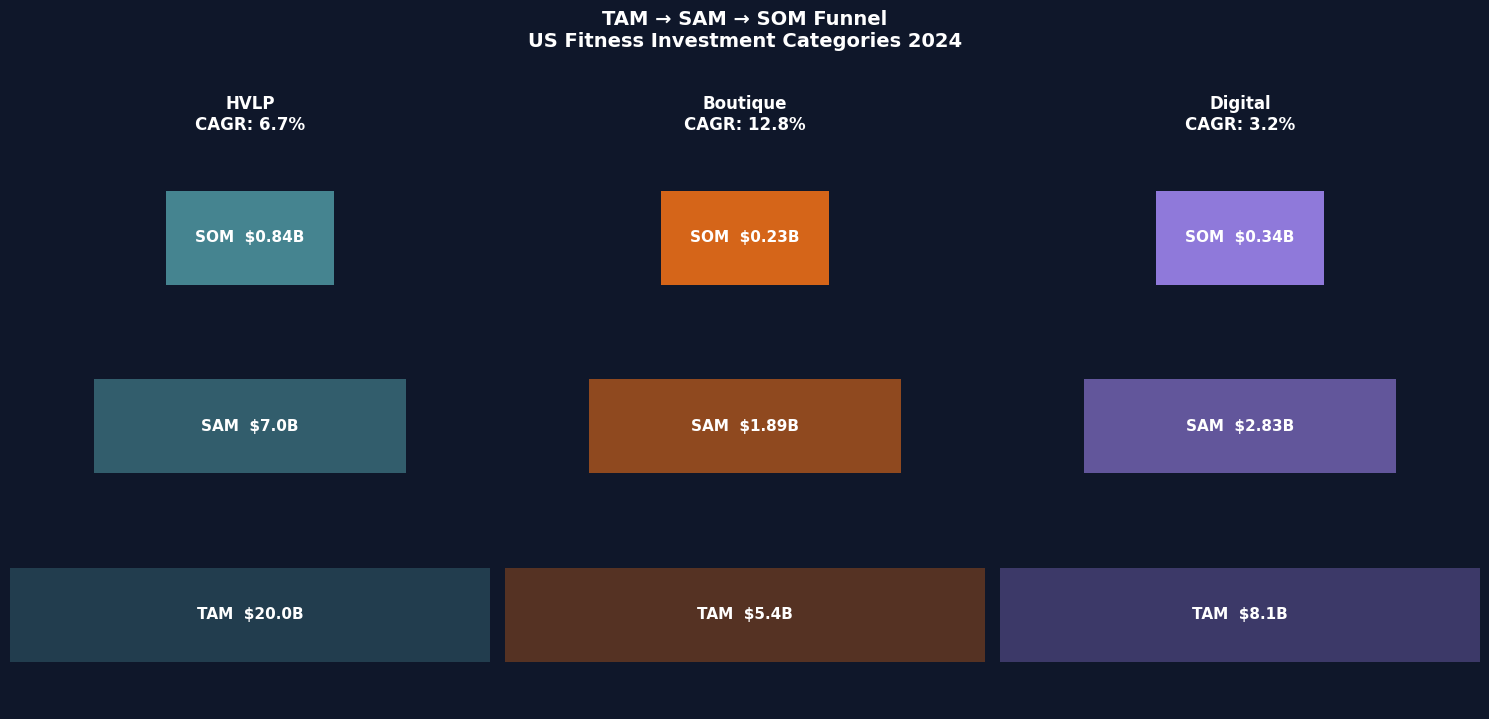

✅ TAM/SAM/SOM funnel saved → output/tam_sam_som.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.patch.set_facecolor('#0f172a')

for ax, cat in zip(axes, categories):
    ax.set_facecolor('#0f172a')
    d = market_data[cat]
    color = colors[cat]

    levels   = ['TAM', 'SAM', 'SOM']
    values   = [d['TAM_B'], d['SAM_B'], d['SOM_B']]
    widths   = [1.0, 0.65, 0.35]
    alphas   = [0.3, 0.55, 0.85]

    for i, (lbl, val, w, alpha) in enumerate(zip(levels, values, widths, alphas)):
        bar = ax.barh(i, w, height=0.5, color=color, alpha=alpha,
                      left=(1 - w) / 2, align='center')
        ax.text(0.5, i, f'{lbl}  ${val}B',
                ha='center', va='center',
                color='white', fontsize=11, fontweight='bold')

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, 2.5)
    ax.axis('off')
    ax.set_title(f'{cat}\nCAGR: {d["CAGR"]}%',
                 color='white', fontsize=12, fontweight='bold', pad=10)

fig.suptitle('TAM → SAM → SOM Funnel\nUS Fitness Investment Categories 2024',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'output', 'tam_sam_som.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ TAM/SAM/SOM funnel saved → output/tam_sam_som.png")

## Bubble Chart (TAM vs CAGR vs PE capital)

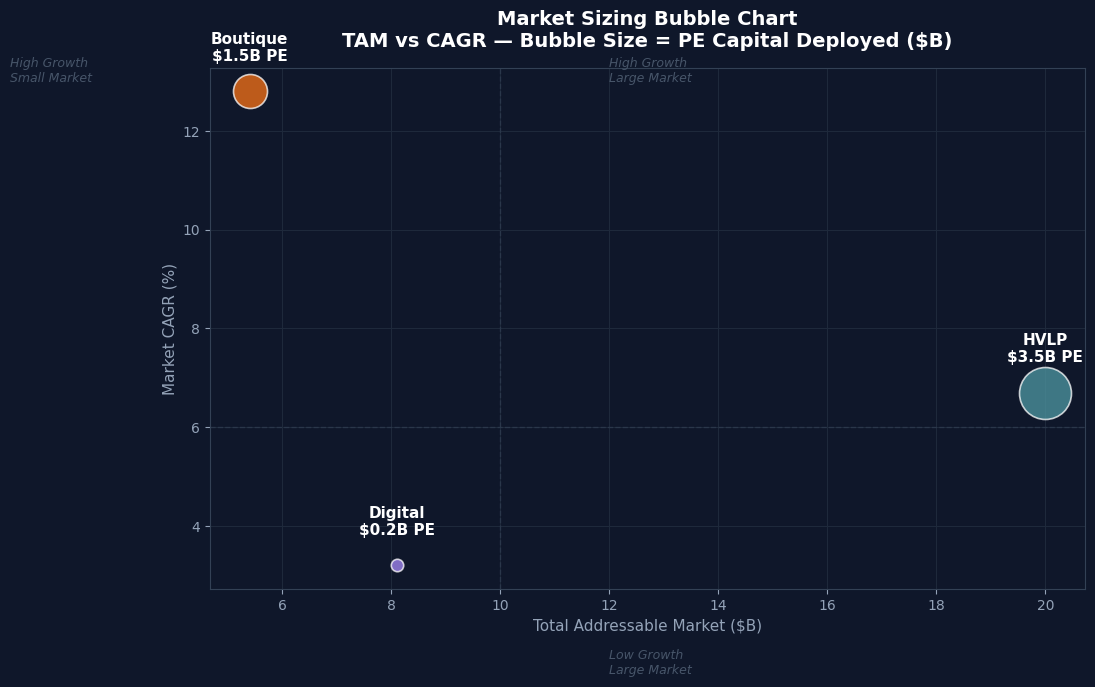

✅ Bubble chart saved → output/bubble_chart.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

for cat, d in market_data.items():
    size = d['PE_Capital_B'] * 400   # bubble size = PE capital deployed
    ax.scatter(
        d['TAM_B'], d['CAGR'],
        s=size, color=colors[cat],
        alpha=0.75, edgecolors='white',
        linewidths=1.2, zorder=3
    )
    ax.annotate(
        f"{cat}\n${d['PE_Capital_B']}B PE",
        xy=(d['TAM_B'], d['CAGR']),
        xytext=(0, 22), textcoords='offset points',
        ha='center', color='white',
        fontsize=11, fontweight='bold'
    )

ax.set_xlabel('Total Addressable Market ($B)', color='#94a3b8', fontsize=11)
ax.set_ylabel('Market CAGR (%)', color='#94a3b8', fontsize=11)
ax.set_title('Market Sizing Bubble Chart\nTAM vs CAGR — Bubble Size = PE Capital Deployed ($B)',
             color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='#94a3b8')
ax.yaxis.grid(True, color='#1e293b', linewidth=0.8)
ax.xaxis.grid(True, color='#1e293b', linewidth=0.8)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_edgecolor('#334155')

# Quadrant labels
ax.axhline(y=6, color='#334155', linewidth=1, linestyle='--', alpha=0.6)
ax.axvline(x=10, color='#334155', linewidth=1, linestyle='--', alpha=0.6)
ax.text(1, 13, 'High Growth\nSmall Market', color='#475569', fontsize=9, style='italic')
ax.text(12, 13, 'High Growth\nLarge Market', color='#475569', fontsize=9, style='italic')
ax.text(12, 1, 'Low Growth\nLarge Market', color='#475569', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'output', 'bubble_chart.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ Bubble chart saved → output/bubble_chart.png")

## Members vs Revenue per site 

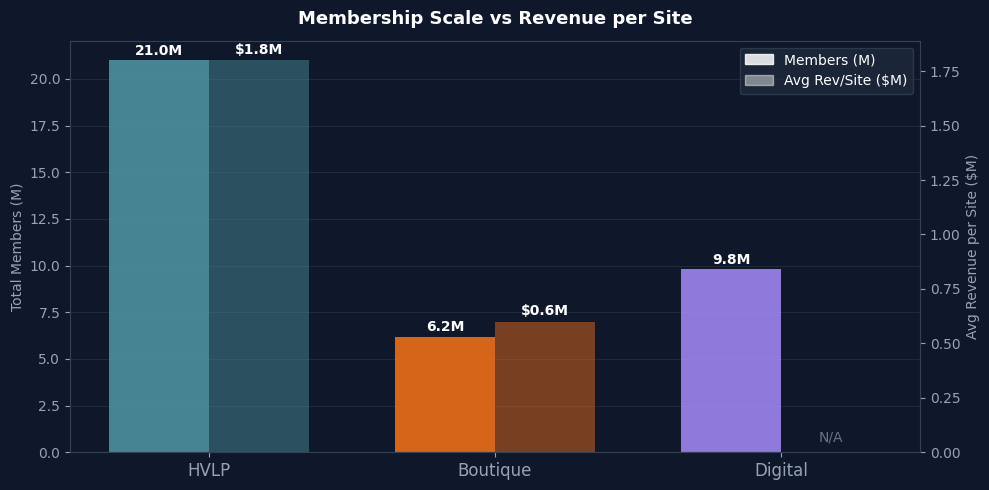

✅ Members vs revenue chart saved → output/members_vs_revenue.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

x = np.arange(len(categories))
members = [market_data[c]['Members_M'] for c in categories]
rev_site = [market_data[c]['Avg_Rev_Site'] for c in categories]
width = 0.35

bars1 = ax.bar(x - width/2, members, width, color=[colors[c] for c in categories],
               alpha=0.85, label='Members (M)')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, rev_site, width, color=[colors[c] for c in categories],
                alpha=0.45, label='Avg Rev/Site ($M)')

for bar, val in zip(bars1, members):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}M', ha='center', color='white', fontsize=10, fontweight='bold')

for bar, val in zip(bars2, rev_site):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'${val}M', ha='center', color='white', fontsize=10, fontweight='bold')
    else:
        ax2.text(bar.get_x() + bar.get_width()/2, 0.05,
                 'N/A', ha='center', color='#64748b', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(categories, color='white', fontsize=12)
ax.set_ylabel('Total Members (M)', color='#94a3b8', fontsize=10)
ax2.set_ylabel('Avg Revenue per Site ($M)', color='#94a3b8', fontsize=10)
ax.tick_params(colors='#94a3b8')
ax2.tick_params(colors='#94a3b8')
for spine in ax.spines.values():
    spine.set_edgecolor('#334155')
for spine in ax2.spines.values():
    spine.set_edgecolor('#334155')
ax.yaxis.grid(True, color='#1e293b', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_title('Membership Scale vs Revenue per Site',
             color='white', fontsize=13, fontweight='bold', pad=12)

lines = [mpatches.Patch(color='white', alpha=0.85, label='Members (M)'),
         mpatches.Patch(color='white', alpha=0.45, label='Avg Rev/Site ($M)')]
legend = ax.legend(handles=lines, facecolor='#1e293b', edgecolor='#334155')
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'output', 'members_vs_revenue.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ Members vs revenue chart saved → output/members_vs_revenue.png")

## PE Capital vs MArket Oppurtunity Summary Print

In [8]:
print("=" * 60)
print("MARKET SIZING SUMMARY — PE INVESTMENT LENS")
print("=" * 60)
for cat in categories:
    d = market_data[cat]
    efficiency = round(d['TAM_B'] / d['PE_Capital_B'], 1) if d['PE_Capital_B'] > 0 else 'N/A'
    print(f"\n{cat}")
    print(f"  TAM:            ${d['TAM_B']}B")
    print(f"  CAGR:           {d['CAGR']}%")
    print(f"  PE Capital In:  ${d['PE_Capital_B']}B")
    print(f"  TAM/PE Ratio:   {efficiency}x  ← market $ per PE $ invested")
    print(f"  Members:        {d['Members_M']}M")
print("\n✅ Higher TAM/PE ratio = more untapped runway per PE dollar")

MARKET SIZING SUMMARY — PE INVESTMENT LENS

HVLP
  TAM:            $20.0B
  CAGR:           6.7%
  PE Capital In:  $3.5B
  TAM/PE Ratio:   5.7x  ← market $ per PE $ invested
  Members:        21.0M

Boutique
  TAM:            $5.4B
  CAGR:           12.8%
  PE Capital In:  $1.5B
  TAM/PE Ratio:   3.6x  ← market $ per PE $ invested
  Members:        6.2M

Digital
  TAM:            $8.1B
  CAGR:           3.2%
  PE Capital In:  $0.2B
  TAM/PE Ratio:   40.5x  ← market $ per PE $ invested
  Members:        9.8M

✅ Higher TAM/PE ratio = more untapped runway per PE dollar
